# Solución al Ejercicio 1 - Autómatas Celulares (Sección 2.10)

Para definir formalmente un Autómata Celular, debemos establecer: La Célula, El Retículo, La Vecindad, El Alfabeto (estados) y las Reglas de Transición.

---

### 1. Escenario: La Casa (Dinámica de Ruido y Concentración)
Modelado de cómo el ruido o la actividad se contagia en un espacio cerrado.
* **El Retículo:** Las habitaciones de la casa.
* **La Célula ($c$):** Cada miembro de la familia.
* **El Alfabeto ($w$):**
  * `0`: Silencio absoluto (ej. durmiendo/estudiando).
  * `1`: Actividad moderada (ej. viendo TV a bajo volumen).
  * `2`: Actividad ruidosa (ej. música alta).
  * `3`: Intervención (ej. pidiendo silencio).
* **La Vecindad ($U$):** Personas en la misma habitación o adyacente.
* **Reglas de Transición ($f$):**
  1. Si $c(t) = 1$ y al menos 2 vecinos están en estado `2`, entonces $c(t+1) = 2$ (contagio de ruido).
  2. Si $c(t) = 0$ y al menos 1 vecino está en estado `2`, entonces $c(t+1) = 3$ (tolerancia límite, pide silencio).
  3. Si hay al menos 1 vecino en estado `3`, todas las células en estado `2` pasan a estado `1` o `0` (restauración del orden).

---

### 2. Escenario: La Universidad (Atención vs. Distracción)
Modelado de cómo se propaga la distracción en el aula.
* **El Retículo:** La cuadrícula de pupitres.
* **La Célula ($c$):** Estudiante.
* **El Alfabeto ($w$):**
  * `0`: Concentrado.
  * `1`: Distraído pasivo (mirando celular).
  * `2`: Distraído activo (conversando).
* **La Vecindad ($U$):** Vecindad de Moore (los 8 estudiantes alrededor).
* **Reglas de Transición ($f$):**
  1. Si $c(t) = 0$ y $\ge 3$ vecinos están en estado `2`, entonces $c(t+1) = 1$.
  2. Si $c(t) = 1$ y 1 vecino lateral está en estado `2`, entonces $c(t+1) = 2$.
  3. *Regla Probabilística (Efecto Profesor):* Si el profesor llama la atención, las células en estado `1` y `2` tienen alta probabilidad de volver a `0`.

---

### 3. Escenario: Medio de Transporte (Espacio Personal)
Comportamiento en un autobús que se llena progresivamente.
* **El Retículo:** El piso del vagón.
* **La Célula ($c$):** Pasajero.
* **El Alfabeto ($w$):**
  * `0`: Aislado (espacio personal amplio).
  * `1`: Cómodo (sin contacto físico).
  * `2`: Invadido (contacto físico incómodo).
  * `3`: En movimiento (buscando espacio).
* **La Vecindad ($U$):** Vecindad de Von Neumann (4 celdas ortogonales: norte, sur, este, oeste).
* **Reglas de Transición ($f$):**
  1. Si $c(t) = 0$ o $1$, y 2 o más celdas vecinas se ocupan, $c(t+1) = 2$.
  2. Si $c(t) = 2$ y percibe una celda vecina vacía, $c(t+1) = 3$.
  3. Si $c(t) = 3$ y ocupa la celda vacía, vuelve a estado `0`. Si no puede moverse, regresa a estado `2`.

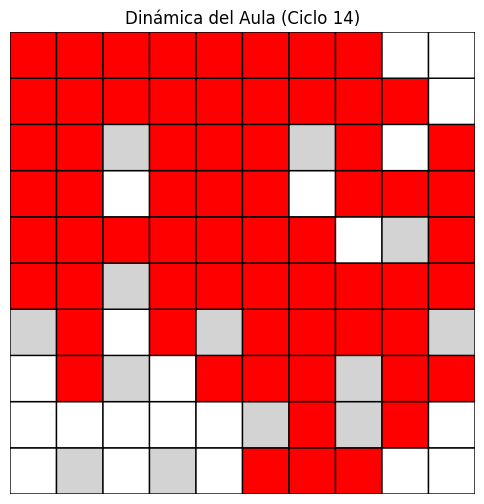

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import time
from IPython.display import clear_output

# Parámetros del salón de clases (Retículo)
FILAS = 10
COLUMNAS = 10
CICLOS = 15

# Alfabeto de estados (w):
# 0: Concentrado (Blanco)
# 1: Distraído Pasivo (Gris)
# 2: Distraído Activo / Hablando (Rojo)
colores = ListedColormap(['white', 'lightgray', 'red'])

# Configuración inicial aleatoria del autómata
# La mayoría empieza concentrada (0), con algunos distraídos (1 y 2)
salon = np.random.choice([0, 1, 2], size=(FILAS, COLUMNAS), p=[0.7, 0.2, 0.1])

def contar_vecinos_moore(matriz, fila, col, estado_buscado):
    """Cuenta los vecinos en un estado específico usando la Vecindad de Moore"""
    filas, columnas = matriz.shape
    conteo = 0
    for i in range(-1, 2):
        for j in range(-1, 2):
            if i == 0 and j == 0:
                continue
            # Condiciones de frontera (paredes del salón)
            if 0 <= fila + i < filas and 0 <= col + j < columnas:
                if matriz[fila + i, col + j] == estado_buscado:
                    conteo += 1
    return conteo

# Simulación del Autómata Celular
for t in range(CICLOS):
    clear_output(wait=True)

    # Dibujar el estado actual
    plt.figure(figsize=(6, 6))
    plt.pcolor(salon[::-1], cmap=colores, edgecolors='k', linewidths=1)
    plt.title(f"Dinámica del Aula (Ciclo {t})")
    plt.axis('off')
    plt.show()

    nuevo_salon = salon.copy()

    # Aplicar reglas de transición en paralelo a todas las células
    for f in range(FILAS):
        for c in range(COLUMNAS):
            estado_actual = salon[f, c]

            # Conteo de vecinos en estado 2 (Hablando)
            vecinos_hablando = contar_vecinos_moore(salon, f, c, 2)

            # Regla A: De concentrado a distraído pasivo si hay mucho ruido
            if estado_actual == 0 and vecinos_hablando >= 3:
                nuevo_salon[f, c] = 1

            # Regla B: De distraído pasivo a hablando si hay algún vecino hablando
            elif estado_actual == 1 and vecinos_hablando >= 1:
                nuevo_salon[f, c] = 2

            # Regla C (Probabilística): Efecto del profesor (Llamado de atención aleatorio)
            # Hay un 10% de probabilidad en cada ciclo de que los alumnos se callen
            if np.random.rand() < 0.10:
                if estado_actual in [1, 2]:
                    nuevo_salon[f, c] = 0

    salon = nuevo_salon
    time.sleep(0.5)